# Problem
One of the critical challenges in deploying conversational agents in production environments is managing the exponentially growing chat history. As conversations extend, two fundamental issues emerge:

1. **Context Window Overflow**: Chat histories frequently exceed LLM context windows, causing models to reject requests or truncate essential conversation context
2. **Performance Degradation**: Large token sequences significantly impact model performance, leading to slower response times and higher computational costs

These issues become particularly problematic in production systems where cost efficiency and response quality directly impact user experience and operational viability.

# Solution
While many sophisticated memory management approaches exist for conversational agents, this notebook demonstrates a simple and effective technique that handles growing chat histories through summarization. This approach can reduce token costs by up to 80% while maintaining conversation context.

The solution implements conditional memory management that automatically triggers when message thresholds are exceeded, ensuring  balance between cost efficiency and conversational coherence.

In [1]:
# Import libraries
import sys, os
import logging
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
from typing_extensions import TypedDict, Annotated, Optional

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables.graph import MermaidDrawMethod
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, RemoveMessage

# Import settings and sensitive variables from config
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from src.config.config import config

print(f"App name: {config.app.name}, version: {config.app.version}")

2025-09-27 19:55:16,080 - root - INFO - Configuration loaded for environment: development


App name: agent-memory-optimization, version: 1.0.0


In [2]:
# Set langsmith project
os.environ["LANGSMITH_API_KEY"] = config.llm.langsmith_api_key.get_secret_value()
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = config.llm.langsmith_project

# Suppress all debug logs from urllib3 and langsmith
logging.getLogger("urllib3").setLevel(logging.WARNING)
logging.getLogger("langsmith").setLevel(logging.WARNING)
logging.getLogger("openai._base_client").setLevel(logging.WARNING)
logging.getLogger("openai._base_client").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("websockets.client").setLevel(logging.WARNING)
logging.getLogger("pyppeteer").setLevel(logging.WARNING)

In [3]:
# Create ChatModel instance
llm = ChatOpenAI(api_key=config.llm.api_key.get_secret_value(), model=config.llm.model_name)

In [4]:
# create graph state
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    summary: Optional[str]

In [5]:
# Prompts
assistant_system_message = PromptTemplate(
    input_variables=["summary"],
    template="""You are a helpful assistant. You are given a conversation history and a summary of the conversation so far. Your task is to respond to the user's message.\n\nsummary of conversations so far: ```{summary}```"""
)

summary_update_template = PromptTemplate(
    input_variables=["existing_summary", "new_messages"],
    template="""You are tasked with updating a conversation summary.

EXISTING SUMMARY:
{existing_summary}

NEW MESSAGES SINCE LAST SUMMARY:
{new_messages}

INSTRUCTIONS:
1. Keep ALL important information from the existing summary
2. Add new relevant information from the recent messages
3. Create a comprehensive, cumulative summary that includes both old and new context
4. Do not lose any important details from the previous summary

Updated Summary:"""
)

summary_initial_template = PromptTemplate(
    input_variables=["messages"],
    template="""Create a comprehensive summary of this conversation:

MESSAGES:
{messages}

Summary:"""
)

In [6]:
# Nodes
def assistant(state: State):
    """
    This node is responsible for responding to the user's message.
    It creates a system message with the summary if it exists and invokes the LLM.
    """
    # Get messages and summary if exists
    messages = state["messages"]
    summary = state.get("summary", "")

    # Create the system message with summary
    system_message = SystemMessage(content=assistant_system_message.format(summary=summary))

    # Invoke LLM
    response = llm.invoke([system_message] + messages)

    # Write response to state
    return {"messages": [response]}


def summarize_conversation(state: State):
    """
    This Node is responsible for summarizing the conversation.
    It creates a cumulative summary that builds upon the previous one.
    """
    # Get messages and existing summary
    messages = state["messages"]
    existing_summary = state.get("summary", "")

    # Format message content for the prompt
    message_contents = [message.content for message in messages]

    # Create our summarization prompt that ensures cumulative behavior
    if existing_summary:
        # Update existing summary
        summary_prompt = summary_update_template.format(
            existing_summary=existing_summary,
            new_messages=message_contents
        )
    else:
        # Create an initial summary
        summary_prompt = summary_initial_template.format(
            messages=message_contents
        )

    # Create the summarization request
    summary_messages = [HumanMessage(content=summary_prompt)]
    summary_response = llm.invoke(summary_messages)

    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]

    # Return the CUMULATIVE summary and deleted messages
    return {"summary": summary_response.content, "messages": delete_messages}

In [7]:
# Router
def router(state: State):
    """
    This function is responsible for deciding which node to invoke after the assistant node.
    If the number of messages is less than 6, it finishes the workflow, otherwise it invokes the summarizer.
    """
    # Check if there are any messages first
    if not state["messages"]:
        return "END"

    return "summarize_conversation" if len(state["messages"]) > 6 else END

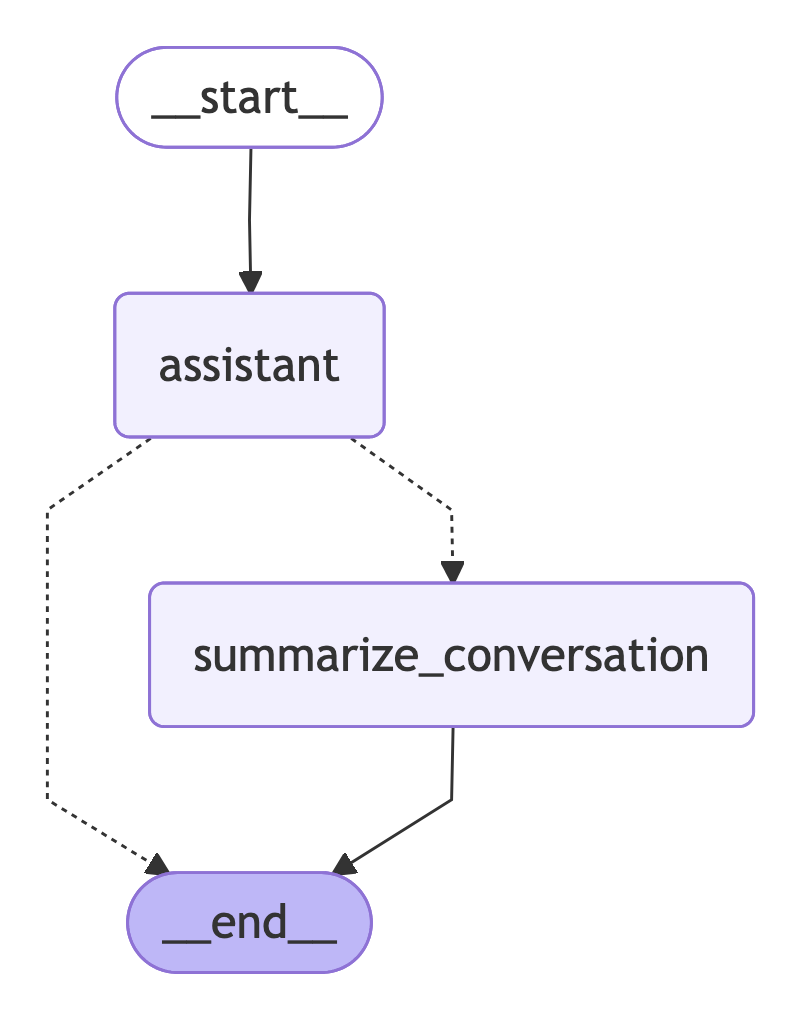

In [8]:
# Workflow Implementation
workflow = StateGraph(State)

workflow.add_node("assistant", assistant)
workflow.add_node("summarize_conversation", summarize_conversation)

workflow.add_edge(START, "assistant")
workflow.add_conditional_edges("assistant", router, ["summarize_conversation", END])
workflow.add_edge("summarize_conversation", END)

memory = InMemorySaver()
graph = workflow.compile(checkpointer=memory)

# Visualize graph
import nest_asyncio
nest_asyncio.apply()
graph.get_graph().draw_mermaid_png(
    output_file_path="workflow_diagram.png",
    draw_method=MermaidDrawMethod.PYPPETEER
)
display(Image("workflow_diagram.png", width=200))

In [9]:
# Test
def conversation_test():
    """Conversation testing with clean output display"""

    # Configuration
    thread = {"configurable": {"thread_id": "memory-test"}}
    test_messages = [
        "what is 2+2",
        "How old is Ronaldo?",
        "What is the capital of France?",
        "What is 3 times 2",
        "What is Golang?",
        "What is the capital of Spain?",
        "What is the capital of the United States?"
    ]

    # Beautiful header
    print("="*60)
    print("CONVERSATION MEMORY MANAGEMENT TEST")
    print("="*60)
    print(f"Total messages: {len(test_messages)}")
    print(f"Summarization threshold: >6 messages")
    print("="*60 + "\n")

    conversation_summary = None

    for i, message in enumerate(test_messages, 1):
        # Beautiful message header
        print(f"Message {i}/{len(test_messages)}")
        print(f"User: {message}")

        try:
            # FIXED: Proper message format with HumanMessage
            result = graph.invoke({
                "messages": [HumanMessage(content=message)]
            }, config=thread)

            # Extract and display assistant response
            if result.get("messages"):
                assistant_response = result["messages"][-1].content
                print(f"Assistant: {assistant_response}")

            # Track summarization
            current_summary = result.get("summary")
            if current_summary and current_summary != conversation_summary:
                print(f"\nSUMMARY UPDATED!")
                print(f"Summary: {current_summary}")
                conversation_summary = current_summary

            # Memory stats
            message_count = len(result.get("messages", []))
            print(f"Messages in memory: {message_count}")

            # Special indicators
            if i == 7:
                print("SUMMARIZATION TRIGGERED!")

        except Exception as e:
            print(f"Error: {e}")

        print("-" * 50)

    # Beautiful footer
    print("\n" + "="*60)
    print("CONVERSATION TEST COMPLETED")
    if conversation_summary:
        print(f"\n📋 FINAL SUMMARY:")
        print(f"{conversation_summary}")
    print("="*60)

# Run the beautiful test
conversation_test()

CONVERSATION MEMORY MANAGEMENT TEST
Total messages: 7
Summarization threshold: >6 messages

Message 1/7
User: what is 2+2
Assistant: 2+2 equals 4.
Messages in memory: 2
--------------------------------------------------
Message 2/7
User: How old is Ronaldo?
Assistant: Cristiano Ronaldo was born on February 5, 1985. As of the current year, 2022, he is 37 years old.
Messages in memory: 4
--------------------------------------------------
Message 3/7
User: What is the capital of France?
Assistant: The capital of France is Paris.
Messages in memory: 6
--------------------------------------------------
Message 4/7
User: What is 3 times 2
Assistant: 3 times 2 equals 6.

SUMMARY UPDATED!
Summary: The conversation involved several questions and answers. These included a basic mathematics question where 2 plus 2 was confirmed to be 4, and 3 times 2 equals 6. There was a question about the age of the footballer Cristiano Ronaldo, who was stated to be 37 years old in 2022. There was also a geogra